In [66]:
import os
from dotenv import load_dotenv
load_dotenv()
os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
os.environ["HUGGINGFACEHUB_API_TOKEN"]=os.getenv("HUGGINGFACEHUB_API_TOKEN")

In [67]:
from langchain_groq import ChatGroq

llm=ChatGroq(model="openai/gpt-oss-120b")

In [68]:
from langchain_community.document_loaders import TextLoader
from langchain_huggingface import HuggingFaceEndpointEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_community.tools import Tool

In [69]:
def retriever_tool(file,name,desc):#"../resourse/sample_docs.txt"

    loader=TextLoader(file,encoding="utf-8").load()
    chunks=RecursiveCharacterTextSplitter(chunk_size=500,chunk_overlap=20).split_documents(loader)

    embeddings=HuggingFaceEndpointEmbeddings(
        repo_id="sentence-transformers/all-MiniLM-L6-v2",
        task="feature-extraction"
    )
    store=FAISS.from_documents(chunks,embeddings)
    retriever=store.as_retriever()
    def generate_func_tool(query : str):
        response=retriever.invoke(query)
        return "/n/n".join(item.page_content for item in response)
    return Tool(name=name,description=desc,func=generate_func_tool)


internal_tool_1=retriever_tool("../resourse/sample_docs.txt","reseach_tool","it will search of any relative docs about query")

internal_tool_1

Tool(name='reseach_tool', description='it will search of any relative docs about query', func=<function retriever_tool.<locals>.generate_func_tool at 0x7fc36f560b80>)

In [70]:
from langchain_community.tools.tavily_search import TavilySearchResults

search=TavilySearchResults(max_results=1)



In [71]:
from langchain_core.messages import BaseMessage,HumanMessage
from langgraph.graph import END,MessagesState,START,StateGraph
def get_next_node(last_message:BaseMessage,goto:str):
    if "Final Answer" in last_message:
        return END
    return goto

In [72]:
def system_prompt(suffix:str):
     return (
        "You are a helpful AI assistant, collaborating with other assistants."
        " Use the provided tools to progress towards answering the question."
        " If you are unable to fully answer, that's OK, another assistant with different tools "
        " will help where you left off. Execute what you can to make progress."
        " If you or any of the other assistants have the final answer or deliverable,"
        " prefix your response with Final Answer so the team knows to stop."
        f"\n{suffix}"
    )

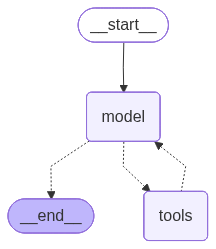

In [73]:
from langchain.agents import create_agent
agent=create_agent(
    llm,
    tools=[internal_tool_1, search],
    system_prompt= system_prompt("You can only do research. Use the tool that you are binded with, you can use both of them" \
    " You are working with a content writer colleague.")
)
agent

In [74]:
from typing import Literal
from langgraph.types import Command
def researcher_node(state:MessagesState)-> Command[Literal[END,"blog_node"]]:
    result=agent.invoke(state)
    goto=get_next_node(result["messages"][-1],"blog_node")
    result["messages"][-1] = HumanMessage(
        content=result["messages"][-1].content, name="searcher"
    )
    return Command(
        update={"messages":result["messages"]},
        goto=goto
    )

researcher_node


<function __main__.researcher_node(state: langgraph.graph.message.MessagesState) -> langgraph.types.Command[typing.Literal['__end__', 'blog_node']]>

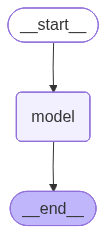

In [75]:
blog_agent=create_agent(
    llm,
    tools=[],
    system_prompt= system_prompt("You can only write a detailed blog. You are working with a researcher colleague."
)
)
blog_agent

In [82]:
from langchain_core.messages import SystemMessage

def blog_node(state: MessagesState):
    # هناخد آخر رسالة فقط (سؤال المستخدم) ونضيف لها System Message بسيط جداً
    # ده هيضمن إننا بعيد تماماً عن الـ 8000 توكن
    simple_messages = [
        SystemMessage(content="You are a helpful blog assistant. Summarize info briefly."),
        state["messages"][-1] 
    ]
    
    # نمرر الرسائل المختصرة فقط
    result = blog_agent.invoke({"messages": simple_messages})
    
    # ... باقي الكود (get_next_node, إلخ)
    return result

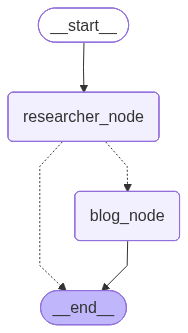

In [83]:
graph=StateGraph(MessagesState)

graph.add_node("blog_node",blog_node)
graph.add_node("researcher_node",researcher_node)


graph.add_edge(START,"researcher_node")

builder=graph.compile()
builder

In [84]:
# ابدأ "على بياض" تماماً
response = builder.invoke(
    {"messages": [("user", "Give me 3 bullet points about Transformers")]},
    config={"configurable": {"thread_id": "2"}} # غير الـ ID هنا
)

In [85]:
response["messages"][-1].content

'**Brief Overview of Transformer Fundamentals**\n\nTransformers have reshaped modern AI by replacing recurrent networks with a **self‑attention mechanism**. This allows every token in a sequence to simultaneously consider all other tokens, capturing rich contextual relationships while enabling massive parallel processing. The architecture stacks identical **encoder and decoder layers**, each receiving token embeddings augmented with **positional encodings** (learned or sinusoidal) that preserve order without recurrence. Because attention calculations are highly parallelizable, Transformers scale efficiently across GPUs/TPUs, delivering state‑of‑the‑art results in NLP (e.g., BERT, GPT) and extending their impact to vision, audio, and multimodal domains.'